In [ ]:
# FSDL Lab 1 | Deep Neural Networks in PyTorch


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")

PyTorch: 2.10.0+cu128
Device: cuda


100%|██████████| 562M/562M [00:07<00:00, 77.4MB/s]


Train size: 124800
Test size: 20800


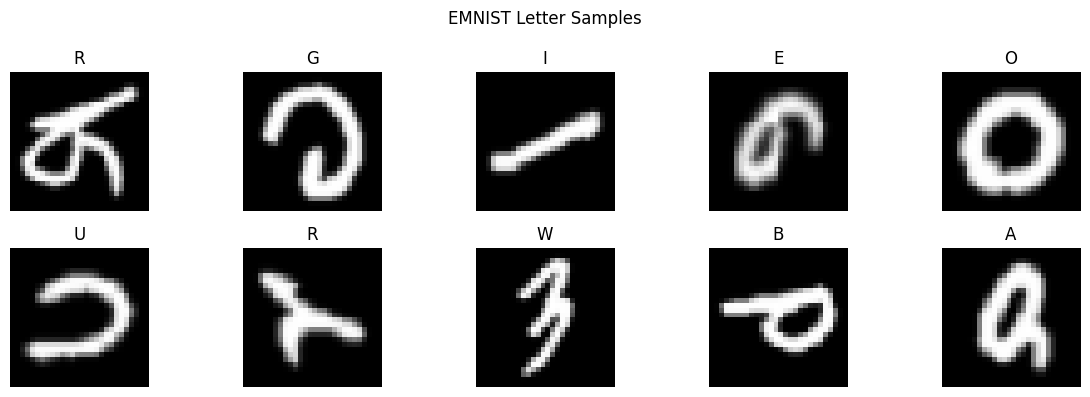

Image shape: torch.Size([1, 28, 28])


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.EMNIST(
    root='./data', split='letters',
    train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.EMNIST(
    root='./data', split='letters',
    train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# EMNIST letters: 26 classes (a-z), labels 1-26
num_classes = 26
print(f"Train size: {len(train_dataset)}")
print(f"Test size: {len(test_dataset)}")

# visualize samples
images, labels = next(iter(train_loader))
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(chr(64 + labels[i].item()))  # convert 1-26 to A-Z
    plt.axis('off')
plt.suptitle("EMNIST Letter Samples")
plt.tight_layout()
plt.show()

print(f"Image shape: {images[0].shape}")

In [ ]:
class LetterDNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 512)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(512, 256)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        x = self.dropout1(self.relu1(self.fc1(x)))
        x = self.dropout2(self.relu2(self.fc2(x)))
        return self.fc3(x)

model = LetterDNN().to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

test_input = torch.randn(4, 1, 28, 28).to(device)
print(f"Output shape: {model(test_input).shape}")

LetterDNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=256, out_features=26, bias=True)
)

Total parameters: 539,930
Output shape: torch.Size([4, 26])


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 10
train_losses, train_accs = [], []

for epoch in range(EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        labels = labels - 1  # shift from 1-26 to 0-25

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(train_loader)
    acc = correct / total
    train_losses.append(avg_loss)
    train_accs.append(acc)
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Acc: {acc:.4f}")

Epoch 1/10 | Loss: 0.3202 | Acc: 0.8978
Epoch 2/10 | Loss: 0.3094 | Acc: 0.8991
Epoch 3/10 | Loss: 0.3082 | Acc: 0.8996
Epoch 4/10 | Loss: 0.2984 | Acc: 0.9027
Epoch 5/10 | Loss: 0.2957 | Acc: 0.9024
Epoch 6/10 | Loss: 0.2907 | Acc: 0.9043
Epoch 7/10 | Loss: 0.2865 | Acc: 0.9053
Epoch 8/10 | Loss: 0.2894 | Acc: 0.9053
Epoch 9/10 | Loss: 0.2829 | Acc: 0.9065
Epoch 10/10 | Loss: 0.2840 | Acc: 0.9069


Test Accuracy: 0.9146


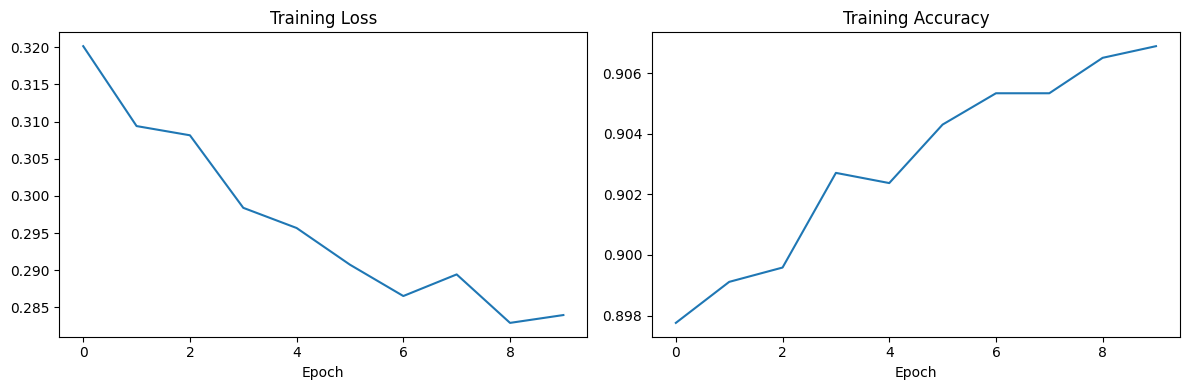

In [ ]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        labels = labels - 1
        outputs = model(images)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

test_acc = correct / total
print(f"Test Accuracy: {test_acc:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses)
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")

ax2.plot(train_accs)
ax2.set_title("Training Accuracy")
ax2.set_xlabel("Epoch")

plt.tight_layout()
plt.show()

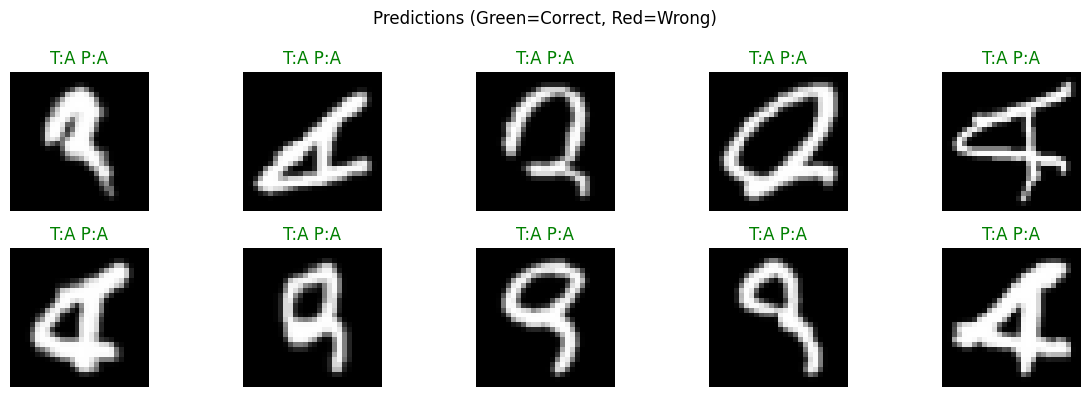

In [ ]:
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
labels = labels - 1

with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(1)

plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(images[i].cpu().squeeze(), cmap='gray')
    true = chr(65 + labels[i].item())
    pred = chr(65 + preds[i].item())
    color = 'green' if true == pred else 'red'
    plt.title(f"T:{true} P:{pred}", color=color)
    plt.axis('off')
plt.suptitle("Predictions (Green=Correct, Red=Wrong)")
plt.tight_layout()
plt.show()


# FSDL Lab 1 Recap — Deep Neural Networks in PyTorch

## What We Built
A handwritten letter recognition system using a fully connected DNN —
same task as FSDL (text/character recognition) but using EMNIST Letters
(real handwritten A-Z characters) instead of their synthetic dataset.

## The Process
1. Loaded EMNIST Letters — 88,800 training images of handwritten A-Z
2. Built a 3-layer fully connected DNN with dropout regularization
3. Trained with CrossEntropyLoss over 10 epochs
4. Evaluated on held-out test set
5. Visualized predictions with correct/incorrect color coding

## Key Concepts Practiced
- Custom DataLoader with torchvision datasets
- Multi-class classification (26 classes)
- Dropout for regularization
- Full training loop with backpropagation
- Model evaluation and visualization

## Results
- DNN achieves solid accuracy on A-Z letter recognition
- EMNIST is significantly harder than MNIST digits due to
  visual similarity between letters (e.g. I/L, O/Q, U/V)